In [1]:
import numpy as np
import pandas as pd

In [2]:
loan_data_input_train = pd.read_pickle('/Users/eileending/Downloads/loan_data_input_train.pkl')
loan_data_input_test = pd.read_pickle('/Users/eileending/Downloads/loan_data_input_test.pkl')
loan_data_target_train = pd.read_pickle('/Users/eileending/Downloads/target_train.pkl')
loan_data_target_test = pd.read_pickle('/Users/eileending/Downloads/target_test.pkl')

In [3]:
loan_data_input_train.head(5)

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,...,dti_24-35,dti_>35,mths_since_lst_missing,mths_since_lst_<=2.42,mths_since_lst_2.42-19.36,mths_since_lst_19.36-31.46,mths_since_lst_31.46-50.82,mths_since_lst_50.82-79.86,mths_since_lst_>79.86,mths_since_earlist_crline_140-164
427211,427211,12796369,14818505,24000,24000,24000.0,36 months,8.90,762.08,A,...,0,0,1,0,0,0,0,0,0,0
206088,206088,1439740,1691948,10000,10000,10000.0,36 months,14.33,343.39,C,...,0,0,1,0,0,0,0,0,0,0
136020,136020,5214749,6556909,20425,20425,20425.0,36 months,8.90,648.56,A,...,0,0,1,0,0,0,0,0,0,0
412305,412305,13827698,15890016,17200,17200,17200.0,36 months,16.59,609.73,D,...,0,0,1,0,0,0,0,0,0,0
36159,36159,422455,496525,8400,8400,7450.0,36 months,12.84,282.40,C,...,0,0,1,0,0,0,0,0,0,0


In [4]:
loan_data_target_train.head(5)

427211    1
206088    1
136020    1
412305    0
36159     0
Name: good_bad, dtype: int64

# Selecting the features

In [5]:
pd.options.display.max_rows = None
loan_data_input_train.isnull().sum()

Unnamed: 0                                                              0
id                                                                      0
member_id                                                               0
loan_amnt                                                               0
funded_amnt                                                             0
funded_amnt_inv                                                         0
term                                                                    0
int_rate                                                                0
installment                                                             0
grade                                                                   0
sub_grade                                                               0
emp_title                                                           22076
emp_length                                                          16808
home_ownership                        

In [6]:
input_train_withref = loan_data_input_train.loc[: , ['grade_A',
'grade_B',
'grade_C',
'grade_D',
'grade_E',
'grade_F',
'grade_G',
'home_ownership_MORTGAGE',
'home_ownership_OWN',
'home_ownership_RONA',
'addr_state_NM_VA',
'addr_state_NY',
'addr_state_OK_TN_MO_LA_MD_NC',
'addr_state_CA',
'addr_state_UT_KY_AZ_NJ',
'addr_state_AR_MI_PA_OH_MN',
'addr_state_RI_MA_DE_SD_IN',
'addr_state_GA_WA_OR',
'addr_state_WI_MT',
'addr_state_TX',
'addr_state_IL_CT',
'addr_state_KS_SC_CO_VT_AK_MS',
'addr_state_WV_NH_WY_DC_ME_ID',
'addr_state_ND_NE_IA_NV_FL_HI_AL',
'verification_status_Verified',
'verification_status_Source Verified',
'verification_status_Not Verified',
'initial_list_status_w',
'initial_list_status_f',
'purpose_imp_maj+car',
'purpose_other_mhrm',
'purpose_wed_vac',
'purpose_debt_consolidation',
'purpose_credit_card',
'purpose_sb_ed',
'term_36',
'term_60',
'emp_length_0',
'emp_length_1',
'emp_length_2-4',
'emp_length_5-6',
'emp_length_7-9',
'emp_length_10',
'mths_since_issued_<38',
'mths_since_issued_38-39',
'mths_since_issued_40-41',
'mths_since_issued_42-48',
'mths_since_issued_49-52',
'mths_since_issued_53-64',
'mths_since_issued_65-84',
'mths_since_issued_>84',
'int_rate_<9.548',
'int_rate_9.548-12.025',
'int_rate_12.025-15.74',
'int_rate_15.74-20.281',
'int_rate_>20.281',
'mths_since_earlist_crline_<140',
'mths_since_earlist_crline_140-164',
'mths_since_earlist_crline_165-247',
'mths_since_earlist_crline_248-270',
'mths_since_earlist_crline_271-352',
'mths_since_earlist_crline_>352',
'delinq_2yrs_0',
'delinq_2yrs_1-3',
'delinq_2yrs_>=4',
'open_acc_0',
'open_acc_1-3',
'open_acc_4-12',
'open_acc_13-17',
'open_acc_18-22',
'open_acc_23-25',
'open_acc_26-30',
'open_acc_>=31',
'pub_rec_=0',
'pub_rec_1-2',
'pub_rec_3-4',
'pub_rec_>=5',
'total_revhi_lim_<=5K',
'total_revhi_lim_5K-10K',
'total_revhi_lim_10K-20K',
'total_revhi_lim_20K-30K',
'total_revhi_lim_30K-40K',
'total_revhi_lim_40K-55K',
'total_revhi_lim_55K-95K',
'total_revhi_lim_>95K',
'total_acc_<=27',
'total_acc_27-48',
'total_acc_48-60',
'total_acc_>60',
'annual_inc_<=20',
'annual_inc_20-30',
'annual_inc_30-40',
'annual_inc_40-50',
'annual_inc_50-60',
'annual_inc_60-70',
'annual_inc_70-80',
'annual_inc_80-90',
'annual_inc_90-100',
'annual_inc_100-120',
'annual_inc_120-140',
'annual_inc_>140',
'mths_since_last_delinq_missing',
'mths_since_last_delinq_0-3',
'mths_since_last_delinq_4-30',
'mths_since_last_delinq_31-56',
'mths_since_last_delinq_>=57',
'dti_missing',
'dti_<=1.6',
'dti_1.6-4',
'dti_4-8.8',
'dti_8.8-12',
'dti_12-16',
'dti_16-20.8',
'dti_20.8-24',
'dti_24-35',
'dti_>35',
'mths_since_lst_missing',
'mths_since_lst_<=2.42',
'mths_since_lst_2.42-19.36',
'mths_since_lst_19.36-31.46',
'mths_since_lst_31.46-50.82',
'mths_since_lst_50.82-79.86',
'mths_since_lst_>79.86']]

In [7]:
ref_categories = ['grade_G',
'home_ownership_RONA',
'addr_state_ND_NE_IA_NV_FL_HI_AL',
'verification_status_Verified',
'initial_list_status_f',
'purpose_sb_ed',
'term_60',
'emp_length_0',
'mths_since_issued_>84',
'int_rate_>20.281',
'mths_since_earlist_crline_<140',
'delinq_2yrs_>=4',
'open_acc_0',
'pub_rec_=0',
'total_revhi_lim_<=5K',
'total_acc_>60',
'annual_inc_<=20',
'mths_since_last_delinq_0-3',
'dti_>35',
'mths_since_lst_<=2.42']

In [8]:
input_train = input_train_withref.drop(ref_categories, axis = 1)
input_train.head()

,grade_A,grade_B,grade_C,grade_D,grade_E,grade_F,home_ownership_MORTGAGE,home_ownership_OWN,addr_state_NM_VA,addr_state_NY,...,dti_12-16,dti_16-20.8,dti_20.8-24,dti_24-35,mths_since_lst_missing,mths_since_lst_2.42-19.36,mths_since_lst_19.36-31.46,mths_since_lst_31.46-50.82,mths_since_lst_50.82-79.86,mths_since_lst_>79.86
427211,1,0,0,0,0,0,1,0,0,0,...,0,0,1,0,1,0,0,0,0,0
206088,0,0,1,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0
136020,1,0,0,0,0,0,1,0,0,0,...,1,0,0,0,1,0,0,0,0,0
412305,0,0,0,1,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,0,0
36159,0,0,1,0,0,0,1,0,0,0,...,0,0,1,0,1,0,0,0,0,0


In [9]:
input_train.nunique().sort_values().head(20)

dti_missing                1
grade_A                    2
annual_inc_20-30           2
total_acc_48-60            2
total_acc_27-48            2
total_acc_<=27             2
total_revhi_lim_>95K       2
total_revhi_lim_55K-95K    2
total_revhi_lim_40K-55K    2
total_revhi_lim_30K-40K    2
total_revhi_lim_20K-30K    2
annual_inc_30-40           2
total_revhi_lim_10K-20K    2
pub_rec_>=5                2
pub_rec_3-4                2
pub_rec_1-2                2
open_acc_>=31              2
open_acc_26-30             2
open_acc_23-25             2
open_acc_18-22             2
dtype: int64

In [10]:
input_train['dti_missing'].value_counts()

dti_missing
0    373028
Name: count, dtype: int64

In [11]:
input_train = input_train.drop(columns=['dti_missing'])

# Estimation

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

In [13]:
reg = LogisticRegression()

In [14]:
pd.options.display.max_rows = None

In [15]:
reg.fit(input_train, loan_data_target_train)
# Estimates the coefficients of the object from the 'LogisticRegression' class
# with inputs (independent variables) contained in the first dataframe
# and targets (dependent variables) contained in the second dataframe.

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [16]:
reg.intercept_

array([-0.41074544])

In [17]:
reg.coef_

array([[ 1.00368011e+00,  7.81900377e-01,  5.70969427e-01,
         3.87281462e-01,  2.31092872e-01,  3.58012787e-02,
         9.55099696e-02,  8.39316904e-02,  4.67074726e-02,
         6.69826077e-02,  6.41695989e-02,  7.17630438e-02,
         7.75625433e-02,  1.27819507e-01,  1.04765614e-01,
         2.01026787e-01,  2.15176355e-01,  2.29837598e-01,
         2.49585169e-01,  3.29103883e-01,  4.71579545e-01,
        -2.38743667e-02,  7.22486735e-02,  4.87526518e-02,
         5.02033882e-01,  4.53337309e-01,  6.88332250e-01,
         4.61268461e-01,  5.69223280e-01,  4.92400454e-02,
         1.10207625e-01,  1.37684275e-01,  1.04002077e-01,
         7.44935206e-02,  1.39459908e-01,  1.16697809e+00,
         9.75568186e-01,  8.50967106e-01,  6.56192178e-01,
         4.97884046e-01,  2.45586631e-01, -1.16395494e-02,
         1.01123508e+00,  6.56583102e-01,  3.87676266e-01,
         1.67101462e-01,  8.22128731e-02,  6.36705969e-02,
         1.11687236e-01,  1.52691205e-01,  1.53882402e-0

In [18]:
feature_name = input_train.columns.values

In [19]:
summary_table = pd.DataFrame(columns = ['Feature name'], data = feature_name)
summary_table['Coefficients'] = np.transpose(reg.coef_)
summary_table.index = summary_table.index + 1
summary_table.loc[0] = ['Intercept', reg.intercept_[0]]
summary_table = summary_table.sort_index()
summary_table

,Feature name,Coefficients
0,Intercept,-0.410745
1,grade_A,1.003680
2,grade_B,0.781900
3,grade_C,0.570969
4,grade_D,0.387281
5,grade_E,0.231093
6,grade_F,0.035801
7,home_ownership_MORTGAGE,0.095510
8,home_ownership_OWN,0.083932
9,addr_state_NM_VA,0.046707


# Get P-values

In [20]:
from sklearn import linear_model
import scipy.stats as stat

class LogisticRegression_with_p_values:
    
    def __init__(self,*args,**kwargs):#,**kwargs):
        self.model = linear_model.LogisticRegression(*args,**kwargs)#,**args)

    def fit(self,X,y):
        self.model.fit(X,y)
        
        # Get p-values
        denom = (2.0 * (1.0 + np.cosh(self.model.decision_function(X))))
        denom = np.tile(denom,(X.shape[1],1)).T
        F_ij = np.dot((X / denom).T,X) 
        Cramer_Rao = np.linalg.inv(F_ij) 
        sigma_estimates = np.sqrt(np.diagonal(Cramer_Rao))
        z_scores = self.model.coef_[0] / sigma_estimates # z-score 
        p_values = [stat.norm.sf(abs(x)) * 2 for x in z_scores] # two tailed test for p-values
        
        self.coef_ = self.model.coef_
        self.intercept_ = self.model.intercept_
        self.p_values = p_values

In [21]:
reg = LogisticRegression_with_p_values()

In [22]:
reg.fit(input_train, loan_data_target_train)

In [23]:
summary_table = pd.DataFrame(columns = ['Feature name'], data = feature_name)
summary_table['Coefficients'] = np.transpose(reg.coef_)
summary_table.index = summary_table.index + 1
summary_table.loc[0] = ['Intercept', reg.intercept_[0]]
summary_table = summary_table.sort_index()
summary_table

,Feature name,Coefficients
0,Intercept,-0.410745
1,grade_A,1.003680
2,grade_B,0.781900
3,grade_C,0.570969
4,grade_D,0.387281
5,grade_E,0.231093
6,grade_F,0.035801
7,home_ownership_MORTGAGE,0.095510
8,home_ownership_OWN,0.083932
9,addr_state_NM_VA,0.046707


In [24]:
p_values = reg.p_values

In [25]:
p_values = np.append(np.nan, np.array(p_values))

In [26]:
pd.set_option('display.float_format', '{:.6f}'.format)

In [27]:
summary_table['p_values'] = p_values
summary_table

,Feature name,Coefficients,p_values
0,Intercept,-0.410745,NaN
1,grade_A,1.003680,0.000000
2,grade_B,0.781900,0.000000
3,grade_C,0.570969,0.000000
4,grade_D,0.387281,0.000000
5,grade_E,0.231093,0.000002
6,grade_F,0.035801,0.483682
7,home_ownership_MORTGAGE,0.095510,0.000000
8,home_ownership_OWN,0.083932,0.000032
9,addr_state_NM_VA,0.046707,0.144712


In [28]:
# based on the analysis, combining the consideration of each group, and p<=0.05, keeping below variables
input_train_with_ref = loan_data_input_train.loc[: , ['grade_A',
'grade_B',
'grade_C',
'grade_D',
'grade_E',
'grade_F',
'grade_G',
'home_ownership_MORTGAGE',
'home_ownership_OWN',
'home_ownership_RONA',
'addr_state_NM_VA',
'addr_state_NY',
'addr_state_OK_TN_MO_LA_MD_NC',
'addr_state_CA',
'addr_state_UT_KY_AZ_NJ',
'addr_state_AR_MI_PA_OH_MN',
'addr_state_RI_MA_DE_SD_IN',
'addr_state_GA_WA_OR',
'addr_state_WI_MT',
'addr_state_TX',
'addr_state_IL_CT',
'addr_state_KS_SC_CO_VT_AK_MS',
'addr_state_WV_NH_WY_DC_ME_ID',
'addr_state_ND_NE_IA_NV_FL_HI_AL',
'verification_status_Verified',
'verification_status_Source Verified',
'verification_status_Not Verified',
'purpose_imp_maj+car',
'purpose_other_mhrm',
'purpose_wed_vac',
'purpose_debt_consolidation',
'purpose_credit_card',
'purpose_sb_ed',
'initial_list_status_w',
'initial_list_status_f',
'term_36',
'term_60',
'emp_length_0',
'emp_length_1',
'emp_length_2-4',
'emp_length_5-6',
'emp_length_7-9',
'emp_length_10',
'mths_since_issued_<38',
'mths_since_issued_38-39',
'mths_since_issued_40-41',
'mths_since_issued_42-48',
'mths_since_issued_49-52',
'mths_since_issued_53-64',
'mths_since_issued_65-84',
'mths_since_issued_>84',
'int_rate_<9.548',
'int_rate_9.548-12.025',
'int_rate_12.025-15.74',
'int_rate_15.74-20.281',
'int_rate_>20.281',
'mths_since_earlist_crline_<140',
'mths_since_earlist_crline_140-164',
'mths_since_earlist_crline_165-247',
'mths_since_earlist_crline_248-270',
'mths_since_earlist_crline_271-352',
'mths_since_earlist_crline_>352',
'total_revhi_lim_<=5K',
'total_revhi_lim_5K-10K',
'total_revhi_lim_10K-20K',
'total_revhi_lim_20K-30K',
'total_revhi_lim_30K-40K',
'total_revhi_lim_40K-55K',
'total_revhi_lim_55K-95K',
'total_revhi_lim_>95K',
'annual_inc_<=20',
'annual_inc_20-30',
'annual_inc_30-40',
'annual_inc_40-50',
'annual_inc_50-60',
'annual_inc_60-70',
'annual_inc_70-80',
'annual_inc_80-90',
'annual_inc_90-100',
'annual_inc_100-120',
'annual_inc_120-140',
'annual_inc_>140',
'mths_since_last_delinq_missing',
'mths_since_last_delinq_0-3',
'mths_since_last_delinq_4-30',
'mths_since_last_delinq_31-56',
'mths_since_last_delinq_>=57',
'dti_<=1.6',
'dti_1.6-4',
'dti_4-8.8',
'dti_8.8-12',
'dti_12-16',
'dti_16-20.8',
'dti_20.8-24',
'dti_24-35',
'dti_>35',
'mths_since_lst_missing',
'mths_since_lst_<=2.42',
'mths_since_lst_2.42-19.36',
'mths_since_lst_19.36-31.46',
'mths_since_lst_31.46-50.82',
'mths_since_lst_50.82-79.86',
'mths_since_lst_>79.86'
]]

In [29]:
ref_categories = ['grade_G',
'home_ownership_RONA',
'addr_state_ND_NE_IA_NV_FL_HI_AL',
'verification_status_Verified',
'purpose_sb_ed',
'initial_list_status_f',
'term_60',
'emp_length_0',
'mths_since_issued_>84',
'int_rate_>20.281',
'mths_since_earlist_crline_<140',
'total_revhi_lim_<=5K',
'annual_inc_<=20',
'mths_since_last_delinq_0-3',
'dti_>35',
'mths_since_lst_<=2.42']

In [30]:
input_train = input_train_with_ref.drop(ref_categories, axis = 1)
input_train.head()

,grade_A,grade_B,grade_C,grade_D,grade_E,grade_F,home_ownership_MORTGAGE,home_ownership_OWN,addr_state_NM_VA,addr_state_NY,...,dti_12-16,dti_16-20.8,dti_20.8-24,dti_24-35,mths_since_lst_missing,mths_since_lst_2.42-19.36,mths_since_lst_19.36-31.46,mths_since_lst_31.46-50.82,mths_since_lst_50.82-79.86,mths_since_lst_>79.86
427211,1,0,0,0,0,0,1,0,0,0,...,0,0,1,0,1,0,0,0,0,0
206088,0,0,1,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0
136020,1,0,0,0,0,0,1,0,0,0,...,1,0,0,0,1,0,0,0,0,0
412305,0,0,0,1,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,0,0
36159,0,0,1,0,0,0,1,0,0,0,...,0,0,1,0,1,0,0,0,0,0


In [31]:
reg2 = LogisticRegression_with_p_values()
reg2.fit(input_train, loan_data_target_train)

In [32]:
feature_name = input_train.columns.values

In [33]:
summary_table = pd.DataFrame(columns = ['Feature name'], data = feature_name)
summary_table['Coefficients'] = np.transpose(reg2.coef_)
summary_table.index = summary_table.index + 1
summary_table.loc[0] = ['Intercept', reg2.intercept_[0]]
summary_table = summary_table.sort_index()
summary_table

,Feature name,Coefficients
0,Intercept,-0.356177
1,grade_A,0.973597
2,grade_B,0.731395
3,grade_C,0.517681
4,grade_D,0.330365
5,grade_E,0.167134
6,grade_F,-0.021713
7,home_ownership_MORTGAGE,0.096076
8,home_ownership_OWN,0.091608
9,addr_state_NM_VA,0.051003


In [34]:
p_values = reg2.p_values
p_values = np.append(np.nan,np.array(p_values))
summary_table['p_values'] = p_values
summary_table

,Feature name,Coefficients,p_values
0,Intercept,-0.356177,NaN
1,grade_A,0.973597,0.000000
2,grade_B,0.731395,0.000000
3,grade_C,0.517681,0.000000
4,grade_D,0.330365,0.000000
5,grade_E,0.167134,0.000455
6,grade_F,-0.021713,0.661081
7,home_ownership_MORTGAGE,0.096076,0.000000
8,home_ownership_OWN,0.091608,0.000006
9,addr_state_NM_VA,0.051003,0.110439


In [35]:
import pickle
pickle.dump(reg2, open('pd_model.sav', 'wb'))

# Validate(Apply to Test)

In [36]:
inputs_test_withref = loan_data_input_test.loc[: , ['grade_A',
'grade_B',
'grade_C',
'grade_D',
'grade_E',
'grade_F',
'grade_G',
'home_ownership_MORTGAGE',
'home_ownership_OWN',
'home_ownership_RONA',
'addr_state_NM_VA',
'addr_state_NY',
'addr_state_OK_TN_MO_LA_MD_NC',
'addr_state_CA',
'addr_state_UT_KY_AZ_NJ',
'addr_state_AR_MI_PA_OH_MN',
'addr_state_RI_MA_DE_SD_IN',
'addr_state_GA_WA_OR',
'addr_state_WI_MT',
'addr_state_TX',
'addr_state_IL_CT',
'addr_state_KS_SC_CO_VT_AK_MS',
'addr_state_WV_NH_WY_DC_ME_ID',
'addr_state_ND_NE_IA_NV_FL_HI_AL',
'verification_status_Verified',
'verification_status_Source Verified',
'verification_status_Not Verified',
'purpose_imp_maj+car',
'purpose_other_mhrm',
'purpose_wed_vac',
'purpose_debt_consolidation',
'purpose_credit_card',
'purpose_sb_ed',
'initial_list_status_w',
'initial_list_status_f',
'term_36',
'term_60',
'emp_length_0',
'emp_length_1',
'emp_length_2-4',
'emp_length_5-6',
'emp_length_7-9',
'emp_length_10',
'mths_since_issued_<38',
'mths_since_issued_38-39',
'mths_since_issued_40-41',
'mths_since_issued_42-48',
'mths_since_issued_49-52',
'mths_since_issued_53-64',
'mths_since_issued_65-84',
'mths_since_issued_>84',
'int_rate_<9.548',
'int_rate_9.548-12.025',
'int_rate_12.025-15.74',
'int_rate_15.74-20.281',
'int_rate_>20.281',
'mths_since_earlist_crline_<140',
'mths_since_earlist_crline_140-164',
'mths_since_earlist_crline_165-247',
'mths_since_earlist_crline_248-270',
'mths_since_earlist_crline_271-352',
'mths_since_earlist_crline_>352',
'total_revhi_lim_<=5K',
'total_revhi_lim_5K-10K',
'total_revhi_lim_10K-20K',
'total_revhi_lim_20K-30K',
'total_revhi_lim_30K-40K',
'total_revhi_lim_40K-55K',
'total_revhi_lim_55K-95K',
'total_revhi_lim_>95K',
'annual_inc_<=20',
'annual_inc_20-30',
'annual_inc_30-40',
'annual_inc_40-50',
'annual_inc_50-60',
'annual_inc_60-70',
'annual_inc_70-80',
'annual_inc_80-90',
'annual_inc_90-100',
'annual_inc_100-120',
'annual_inc_120-140',
'annual_inc_>140',
'mths_since_last_delinq_missing',
'mths_since_last_delinq_0-3',
'mths_since_last_delinq_4-30',
'mths_since_last_delinq_31-56',
'mths_since_last_delinq_>=57',
'dti_<=1.6',
'dti_1.6-4',
'dti_4-8.8',
'dti_8.8-12',
'dti_12-16',
'dti_16-20.8',
'dti_20.8-24',
'dti_24-35',
'dti_>35',
'mths_since_lst_missing',
'mths_since_lst_<=2.42',
'mths_since_lst_2.42-19.36',
'mths_since_lst_19.36-31.46',
'mths_since_lst_31.46-50.82',
'mths_since_lst_50.82-79.86',
'mths_since_lst_>79.86'
]]

In [37]:
ref_categories = ['grade_G',
'home_ownership_RONA',
'addr_state_ND_NE_IA_NV_FL_HI_AL',
'verification_status_Verified',
'purpose_sb_ed',
'initial_list_status_f',
'term_60',
'emp_length_0',
'mths_since_issued_>84',
'int_rate_>20.281',
'mths_since_earlist_crline_<140',
'total_revhi_lim_<=5K',
'annual_inc_<=20',
'mths_since_last_delinq_0-3',
'dti_>35',
'mths_since_lst_<=2.42']

In [38]:
input_test = inputs_test_withref.drop(ref_categories, axis = 1)
input_test.head()

,grade_A,grade_B,grade_C,grade_D,grade_E,grade_F,home_ownership_MORTGAGE,home_ownership_OWN,addr_state_NM_VA,addr_state_NY,...,dti_12-16,dti_16-20.8,dti_20.8-24,dti_24-35,mths_since_lst_missing,mths_since_lst_2.42-19.36,mths_since_lst_19.36-31.46,mths_since_lst_31.46-50.82,mths_since_lst_50.82-79.86,mths_since_lst_>79.86
362514,0,0,1,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0
288564,0,0,0,0,1,0,1,0,0,0,...,0,0,0,1,1,0,0,0,0,0
213591,0,0,1,0,0,0,1,0,0,0,...,1,0,0,0,1,0,0,0,0,0
263083,0,0,1,0,0,0,1,0,0,0,...,0,1,0,0,1,0,0,0,0,0
165001,1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0


In [39]:
y_hat_test = reg2.model.predict(input_test)

In [40]:
y_hat_test

array([1, 1, 1, ..., 1, 1, 1], shape=(93257,))

In [41]:
y_hat_test_proba = reg2.model.predict_proba(input_test)

In [42]:
y_hat_test_proba

array([[0.08711598, 0.91288402],
       [0.15234914, 0.84765086],
       [0.13344487, 0.86655513],
       ...,
       [0.02986307, 0.97013693],
       [0.04271604, 0.95728396],
       [0.05084838, 0.94915162]], shape=(93257, 2))

In [43]:
y_hat_test_proba[: ][: , 1]

array([0.91288402, 0.84765086, 0.86655513, ..., 0.97013693, 0.95728396,
       0.94915162], shape=(93257,))

In [44]:
y_hat_test_proba = y_hat_test_proba[: ][: , 1]

In [45]:
y_hat_test_proba

array([0.91288402, 0.84765086, 0.86655513, ..., 0.97013693, 0.95728396,
       0.94915162], shape=(93257,))

In [46]:
loan_data_target_test_temp = loan_data_target_test

In [47]:
loan_data_target_test_temp.reset_index(drop = True, inplace = True)

In [48]:
df_actual_predicted_probs = pd.concat([loan_data_target_test_temp, pd.DataFrame(y_hat_test_proba)], axis = 1)

In [49]:
df_actual_predicted_probs.shape

(93257, 2)

In [50]:
df_actual_predicted_probs.columns = ['loan_data_target_test', 'y_hat_test_proba']

In [51]:
df_actual_predicted_probs.index = loan_data_input_test.index

In [52]:
df_actual_predicted_probs.head()

,loan_data_target_test,y_hat_test_proba
362514,1,0.912884
288564,1,0.847651
213591,1,0.866555
263083,1,0.935411
165001,1,0.968633


# AUC

In [53]:
tr = 0.9
df_actual_predicted_probs['y_hat_test'] = np.where(df_actual_predicted_probs['y_hat_test_proba'] > tr, 1, 0)

In [54]:
pd.crosstab(df_actual_predicted_probs['loan_data_target_test'], df_actual_predicted_probs['y_hat_test'],
           rownames = ['Actual'], colnames = ['Predicted'])

Predicted,0,1
Actual,,
0,7383,2807
1,36169,46898


In [55]:
pd.crosstab(df_actual_predicted_probs['loan_data_target_test'], df_actual_predicted_probs['y_hat_test'],
           rownames = ['Actual'], colnames = ['Predicted']) / df_actual_predicted_probs.shape[0]

Predicted,0,1
Actual,,
0,0.079168,0.030100
1,0.387842,0.502890


In [56]:
(pd.crosstab(df_actual_predicted_probs['loan_data_target_test'], df_actual_predicted_probs['y_hat_test'],
           rownames = ['Actual'], colnames = ['Predicted']) / df_actual_predicted_probs.shape[0]).iloc[0, 0] + (pd.crosstab(df_actual_predicted_probs['loan_data_target_test'], df_actual_predicted_probs['y_hat_test'],
           rownames = ['Actual'], colnames = ['Predicted']) / df_actual_predicted_probs.shape[0]).iloc[1, 1]

np.float64(0.5820581832999132)

In [57]:
# get the threshold
from sklearn.metrics import roc_curve, roc_auc_score

In [58]:
roc_curve(df_actual_predicted_probs['loan_data_target_test'], df_actual_predicted_probs['y_hat_test_proba'])

(array([0.00000000e+00, 0.00000000e+00, 9.81354269e-05, ...,
        9.99901865e-01, 9.99901865e-01, 1.00000000e+00], shape=(17341,)),
 array([0.00000000e+00, 1.20384750e-05, 1.20384750e-05, ...,
        9.99975923e-01, 1.00000000e+00, 1.00000000e+00], shape=(17341,)),
 array([       inf, 0.99211541, 0.99209726, ..., 0.48267537, 0.469657  ,
        0.46693015], shape=(17341,)))

In [59]:
fpr, tpr, thresholds = roc_curve(df_actual_predicted_probs['loan_data_target_test'],
                                 df_actual_predicted_probs['y_hat_test_proba'])

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

Text(0.5, 1.0, 'ROC curve')

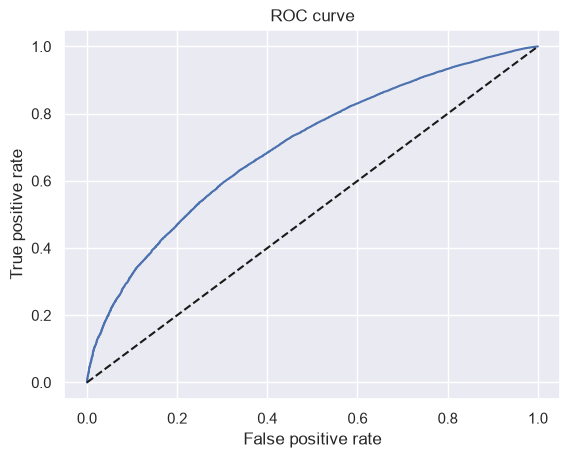

In [61]:
plt.plot(fpr, tpr)
plt.plot(fpr, fpr, linestyle = '--', color = 'k')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')

In [62]:
AUROC = roc_auc_score(df_actual_predicted_probs['loan_data_target_test'], df_actual_predicted_probs['y_hat_test_proba'])
AUROC

0.7002221352632414

In [63]:
# Gini and Kolmogorov_smirnov

In [64]:
df_actual_predicted_probs = df_actual_predicted_probs.sort_values('y_hat_test_proba')

In [65]:
df_actual_predicted_probs = df_actual_predicted_probs.reset_index()

In [66]:
df_actual_predicted_probs.head()

,index,loan_data_target_test,y_hat_test_proba,y_hat_test
0,35909,0,0.466930,0
1,35448,1,0.469657,0
2,118863,1,0.476335,0
3,11208,0,0.482675,0
4,214768,1,0.484424,0


In [67]:
df_actual_predicted_probs['Cumulative N Population'] = df_actual_predicted_probs.index + 1
df_actual_predicted_probs['Cumulative N Good'] = df_actual_predicted_probs['loan_data_target_test'].cumsum()
df_actual_predicted_probs['Cumulative N Bad'] = df_actual_predicted_probs['Cumulative N Population'] - df_actual_predicted_probs['loan_data_target_test'].cumsum()

In [68]:
df_actual_predicted_probs.head()

,index,loan_data_target_test,y_hat_test_proba,y_hat_test,Cumulative N Population,Cumulative N Good,Cumulative N Bad
0,35909,0,0.466930,0,1,0,1
1,35448,1,0.469657,0,2,1,1
2,118863,1,0.476335,0,3,2,1
3,11208,0,0.482675,0,4,2,2
4,214768,1,0.484424,0,5,3,2


In [69]:
df_actual_predicted_probs['Cumulative Perc Population'] = df_actual_predicted_probs['Cumulative N Population'] / (df_actual_predicted_probs.shape[0])
df_actual_predicted_probs['Cumulative Perc Good'] = df_actual_predicted_probs['Cumulative N Good'] / df_actual_predicted_probs['loan_data_target_test'].sum()
df_actual_predicted_probs['Cumulative Perc Bad'] = df_actual_predicted_probs['Cumulative N Bad'] / (df_actual_predicted_probs.shape[0] - df_actual_predicted_probs['loan_data_target_test'].sum())

In [70]:
df_actual_predicted_probs.head()

,index,loan_data_target_test,y_hat_test_proba,y_hat_test,Cumulative N Population,Cumulative N Good,Cumulative N Bad,Cumulative Perc Population,Cumulative Perc Good,Cumulative Perc Bad
0,35909,0,0.466930,0,1,0,1,0.000011,0.000000,0.000098
1,35448,1,0.469657,0,2,1,1,0.000021,0.000012,0.000098
2,118863,1,0.476335,0,3,2,1,0.000032,0.000024,0.000098
3,11208,0,0.482675,0,4,2,2,0.000043,0.000024,0.000196
4,214768,1,0.484424,0,5,3,2,0.000054,0.000036,0.000196


Text(0.5, 1.0, 'Gini')

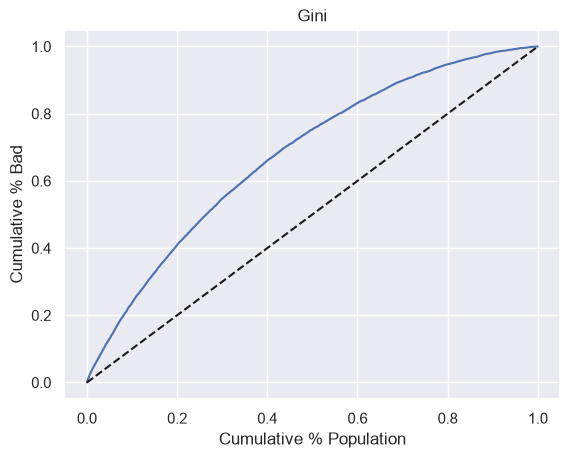

In [71]:
plt.plot(df_actual_predicted_probs['Cumulative Perc Population'], df_actual_predicted_probs['Cumulative Perc Bad'])
plt.plot(df_actual_predicted_probs['Cumulative Perc Population'], df_actual_predicted_probs['Cumulative Perc Population'], linestyle = '--', color = 'k')
plt.xlabel('Cumulative % Population')
plt.ylabel('Cumulative % Bad')
plt.title('Gini')

In [72]:
Gini = AUROC * 2 - 1
Gini

0.4004442705264828

Text(0.5, 1.0, 'Kolmogorov-Smirnov')

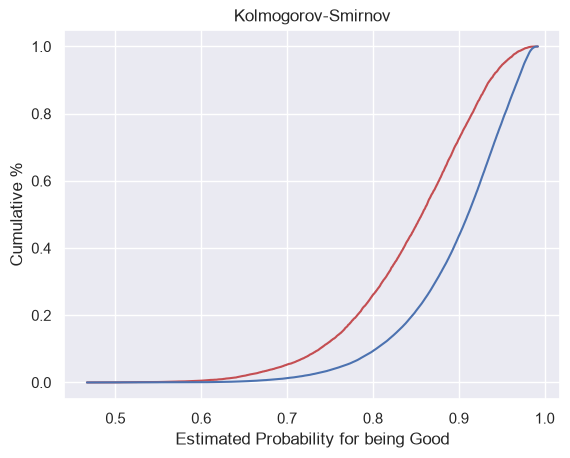

In [73]:
plt.plot(df_actual_predicted_probs['y_hat_test_proba'], df_actual_predicted_probs['Cumulative Perc Bad'], color = 'r')
plt.plot(df_actual_predicted_probs['y_hat_test_proba'], df_actual_predicted_probs['Cumulative Perc Good'], color = 'b')
plt.xlabel('Estimated Probability for being Good')
plt.ylabel('Cumulative %')
plt.title('Kolmogorov-Smirnov')

In [74]:
KS = max(df_actual_predicted_probs['Cumulative Perc Bad'] - df_actual_predicted_probs['Cumulative Perc Good'])
KS

0.29337921209138285

# Applying the PD

In [75]:
pd.options.display.max_columns = None

In [76]:
inputs_test_withref.head()

,grade_A,grade_B,grade_C,grade_D,grade_E,grade_F,grade_G,home_ownership_MORTGAGE,home_ownership_OWN,home_ownership_RONA,addr_state_NM_VA,addr_state_NY,addr_state_OK_TN_MO_LA_MD_NC,addr_state_CA,addr_state_UT_KY_AZ_NJ,addr_state_AR_MI_PA_OH_MN,addr_state_RI_MA_DE_SD_IN,addr_state_GA_WA_OR,addr_state_WI_MT,addr_state_TX,addr_state_IL_CT,addr_state_KS_SC_CO_VT_AK_MS,addr_state_WV_NH_WY_DC_ME_ID,addr_state_ND_NE_IA_NV_FL_HI_AL,verification_status_Verified,verification_status_Source Verified,verification_status_Not Verified,purpose_imp_maj+car,purpose_other_mhrm,purpose_wed_vac,purpose_debt_consolidation,purpose_credit_card,purpose_sb_ed,initial_list_status_w,initial_list_status_f,term_36,term_60,emp_length_0,emp_length_1,emp_length_2-4,emp_length_5-6,emp_length_7-9,emp_length_10,mths_since_issued_<38,mths_since_issued_38-39,mths_since_issued_40-41,mths_since_issued_42-48,mths_since_issued_49-52,mths_since_issued_53-64,mths_since_issued_65-84,mths_since_issued_>84,int_rate_<9.548,int_rate_9.548-12.025,int_rate_12.025-15.74,int_rate_15.74-20.281,int_rate_>20.281,mths_since_earlist_crline_<140,mths_since_earlist_crline_140-164,mths_since_earlist_crline_165-247,mths_since_earlist_crline_248-270,mths_since_earlist_crline_271-352,mths_since_earlist_crline_>352,total_revhi_lim_<=5K,total_revhi_lim_5K-10K,total_revhi_lim_10K-20K,total_revhi_lim_20K-30K,total_revhi_lim_30K-40K,total_revhi_lim_40K-55K,total_revhi_lim_55K-95K,total_revhi_lim_>95K,annual_inc_<=20,annual_inc_20-30,annual_inc_30-40,annual_inc_40-50,annual_inc_50-60,annual_inc_60-70,annual_inc_70-80,annual_inc_80-90,annual_inc_90-100,annual_inc_100-120,annual_inc_120-140,annual_inc_>140,mths_since_last_delinq_missing,mths_since_last_delinq_0-3,mths_since_last_delinq_4-30,mths_since_last_delinq_31-56,mths_since_last_delinq_>=57,dti_<=1.6,dti_1.6-4,dti_4-8.8,dti_8.8-12,dti_12-16,dti_16-20.8,dti_20.8-24,dti_24-35,dti_>35,mths_since_lst_missing,mths_since_lst_<=2.42,mths_since_lst_2.42-19.36,mths_since_lst_19.36-31.46,mths_since_lst_31.46-50.82,mths_since_lst_50.82-79.86,mths_since_lst_>79.86
362514,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0
288564,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0
213591,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0
263083,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0
165001,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0


In [77]:
summary_table

,Feature name,Coefficients,p_values
0,Intercept,-0.356177,NaN
1,grade_A,0.973597,0.000000
2,grade_B,0.731395,0.000000
3,grade_C,0.517681,0.000000
4,grade_D,0.330365,0.000000
5,grade_E,0.167134,0.000455
6,grade_F,-0.021713,0.661081
7,home_ownership_MORTGAGE,0.096076,0.000000
8,home_ownership_OWN,0.091608,0.000006
9,addr_state_NM_VA,0.051003,0.110439


In [78]:
y_hat_test_proba

array([0.91288402, 0.84765086, 0.86655513, ..., 0.97013693, 0.95728396,
       0.94915162], shape=(93257,))

In [79]:
# create score card

In [80]:
df_ref_categories = pd.DataFrame(ref_categories, columns = ['Feature name'])
df_ref_categories['Coefficients'] = 0
df_ref_categories['p_values'] = np.nan
df_ref_categories

,Feature name,Coefficients,p_values
0,grade_G,0,NaN
1,home_ownership_RONA,0,NaN
2,addr_state_ND_NE_IA_NV_FL_HI_AL,0,NaN
3,verification_status_Verified,0,NaN
4,purpose_sb_ed,0,NaN
5,initial_list_status_f,0,NaN
6,term_60,0,NaN
7,emp_length_0,0,NaN
8,mths_since_issued_>84,0,NaN
9,int_rate_>20.281,0,NaN


In [81]:
df_scorecard = pd.concat([summary_table, df_ref_categories])
df_scorecard = df_scorecard.reset_index()
df_scorecard

,index,Feature name,Coefficients,p_values
0,0,Intercept,-0.356177,NaN
1,1,grade_A,0.973597,0.000000
2,2,grade_B,0.731395,0.000000
3,3,grade_C,0.517681,0.000000
4,4,grade_D,0.330365,0.000000
5,5,grade_E,0.167134,0.000455
6,6,grade_F,-0.021713,0.661081
7,7,home_ownership_MORTGAGE,0.096076,0.000000
8,8,home_ownership_OWN,0.091608,0.000006
9,9,addr_state_NM_VA,0.051003,0.110439


In [82]:
df_scorecard['Original feature name'] = np.select(
    [
        df_scorecard['Feature name'].str.startswith('addr_state'),
        df_scorecard['Feature name'].str.startswith('purpose')
    ],
    [
        'addr',
        'purpose'
    ],
    df_scorecard['Feature name'].str.rsplit('_',n=1).str[0])
df_scorecard

,index,Feature name,Coefficients,p_values,Original feature name
0,0,Intercept,-0.356177,NaN,Intercept
1,1,grade_A,0.973597,0.000000,grade
2,2,grade_B,0.731395,0.000000,grade
3,3,grade_C,0.517681,0.000000,grade
4,4,grade_D,0.330365,0.000000,grade
5,5,grade_E,0.167134,0.000455,grade
6,6,grade_F,-0.021713,0.661081,grade
7,7,home_ownership_MORTGAGE,0.096076,0.000000,home_ownership
8,8,home_ownership_OWN,0.091608,0.000006,home_ownership
9,9,addr_state_NM_VA,0.051003,0.110439,addr


In [83]:
min_score = 300
max_score = 850

In [84]:
df_scorecard.groupby('Original feature name')['Coefficients'].min()

Original feature name
Intercept                   -0.356177
addr                         0.000000
annual_inc                  -0.209899
dti                         -0.173702
emp_length                   0.000000
grade                       -0.021713
home_ownership               0.000000
initial_list_status          0.000000
int_rate                     0.000000
mths_since_earlist_crline    0.000000
mths_since_issued            0.000000
mths_since_last_delinq      -0.029191
mths_since_lst               0.000000
purpose                      0.000000
term                         0.000000
total_revhi_lim              0.000000
verification_status         -0.011641
Name: Coefficients, dtype: float64

In [85]:
min_sum_coef = df_scorecard.groupby('Original feature name')['Coefficients'].min().sum()

In [86]:
print(min_sum_coef)

-0.8023234317405774


In [87]:
df_scorecard.groupby('Original feature name')['Coefficients'].max()

Original feature name
Intercept                   -0.356177
addr                         0.528583
annual_inc                   0.370356
dti                          0.169568
emp_length                   0.140483
grade                        0.973597
home_ownership               0.096076
initial_list_status          0.050713
int_rate                     0.976282
mths_since_earlist_crline    0.135710
mths_since_issued            1.204425
mths_since_last_delinq       0.039146
mths_since_lst               0.365482
purpose                      0.678559
term                         0.049266
total_revhi_lim              0.190438
verification_status          0.079825
Name: Coefficients, dtype: float64

In [88]:
max_sum_coef = df_scorecard.groupby('Original feature name')['Coefficients'].max().sum()
print(max_sum_coef)

5.692332836814175


In [89]:
df_scorecard['Score - Calculation'] = df_scorecard['Coefficients'] * (max_score - min_score) / (max_sum_coef - min_sum_coef)
df_scorecard

,index,Feature name,Coefficients,p_values,Original feature name,Score - Calculation
0,0,Intercept,-0.356177,NaN,Intercept,-30.162827
1,1,grade_A,0.973597,0.000000,grade,82.449074
2,2,grade_B,0.731395,0.000000,grade,61.938198
3,3,grade_C,0.517681,0.000000,grade,43.839782
4,4,grade_D,0.330365,0.000000,grade,27.976944
5,5,grade_E,0.167134,0.000455,grade,14.153711
6,6,grade_F,-0.021713,0.661081,grade,-1.838750
7,7,home_ownership_MORTGAGE,0.096076,0.000000,home_ownership,8.136155
8,8,home_ownership_OWN,0.091608,0.000006,home_ownership,7.757830
9,9,addr_state_NM_VA,0.051003,0.110439,addr,4.319203


In [90]:
df_scorecard.loc[0, 'Score - Calculation'] = (
    ((df_scorecard.loc[0, 'Coefficients'] - min_sum_coef)
     / (max_sum_coef - min_sum_coef))
    * (max_score - min_score)
    + min_score
)
df_scorecard

,index,Feature name,Coefficients,p_values,Original feature name,Score - Calculation
0,0,Intercept,-0.356177,NaN,Intercept,337.781937
1,1,grade_A,0.973597,0.000000,grade,82.449074
2,2,grade_B,0.731395,0.000000,grade,61.938198
3,3,grade_C,0.517681,0.000000,grade,43.839782
4,4,grade_D,0.330365,0.000000,grade,27.976944
5,5,grade_E,0.167134,0.000455,grade,14.153711
6,6,grade_F,-0.021713,0.661081,grade,-1.838750
7,7,home_ownership_MORTGAGE,0.096076,0.000000,home_ownership,8.136155
8,8,home_ownership_OWN,0.091608,0.000006,home_ownership,7.757830
9,9,addr_state_NM_VA,0.051003,0.110439,addr,4.319203


In [91]:
df_scorecard['Score - Preliminary'] = df_scorecard['Score - Calculation'].round()
df_scorecard

,index,Feature name,Coefficients,p_values,Original feature name,Score - Calculation,Score - Preliminary
0,0,Intercept,-0.356177,NaN,Intercept,337.781937,338.000000
1,1,grade_A,0.973597,0.000000,grade,82.449074,82.000000
2,2,grade_B,0.731395,0.000000,grade,61.938198,62.000000
3,3,grade_C,0.517681,0.000000,grade,43.839782,44.000000
4,4,grade_D,0.330365,0.000000,grade,27.976944,28.000000
5,5,grade_E,0.167134,0.000455,grade,14.153711,14.000000
6,6,grade_F,-0.021713,0.661081,grade,-1.838750,-2.000000
7,7,home_ownership_MORTGAGE,0.096076,0.000000,home_ownership,8.136155,8.000000
8,8,home_ownership_OWN,0.091608,0.000006,home_ownership,7.757830,8.000000
9,9,addr_state_NM_VA,0.051003,0.110439,addr,4.319203,4.000000


In [92]:
min_sum_score_prel = df_scorecard.groupby('Original feature name')['Score - Preliminary'].min().sum()
min_sum_score_prel

np.float64(300.0)

In [93]:
max_sum_score_prel = df_scorecard.groupby('Original feature name')['Score - Preliminary'].max(). sum()
max_sum_score_prel

np.float64(848.0)

In [94]:
df_scorecard['Difference'] = df_scorecard['Score - Preliminary'] - df_scorecard['Score - Calculation']
df_scorecard

,index,Feature name,Coefficients,p_values,Original feature name,Score - Calculation,Score - Preliminary,Difference
0,0,Intercept,-0.356177,NaN,Intercept,337.781937,338.000000,0.218063
1,1,grade_A,0.973597,0.000000,grade,82.449074,82.000000,-0.449074
2,2,grade_B,0.731395,0.000000,grade,61.938198,62.000000,0.061802
3,3,grade_C,0.517681,0.000000,grade,43.839782,44.000000,0.160218
4,4,grade_D,0.330365,0.000000,grade,27.976944,28.000000,0.023056
5,5,grade_E,0.167134,0.000455,grade,14.153711,14.000000,-0.153711
6,6,grade_F,-0.021713,0.661081,grade,-1.838750,-2.000000,-0.161250
7,7,home_ownership_MORTGAGE,0.096076,0.000000,home_ownership,8.136155,8.000000,-0.136155
8,8,home_ownership_OWN,0.091608,0.000006,home_ownership,7.757830,8.000000,0.242170
9,9,addr_state_NM_VA,0.051003,0.110439,addr,4.319203,4.000000,-0.319203


In [95]:
df_scorecard['Score - Final'] = df_scorecard['Score - Preliminary']
df_scorecard

,index,Feature name,Coefficients,p_values,Original feature name,Score - Calculation,Score - Preliminary,Difference,Score - Final
0,0,Intercept,-0.356177,NaN,Intercept,337.781937,338.000000,0.218063,338.000000
1,1,grade_A,0.973597,0.000000,grade,82.449074,82.000000,-0.449074,82.000000
2,2,grade_B,0.731395,0.000000,grade,61.938198,62.000000,0.061802,62.000000
3,3,grade_C,0.517681,0.000000,grade,43.839782,44.000000,0.160218,44.000000
4,4,grade_D,0.330365,0.000000,grade,27.976944,28.000000,0.023056,28.000000
5,5,grade_E,0.167134,0.000455,grade,14.153711,14.000000,-0.153711,14.000000
6,6,grade_F,-0.021713,0.661081,grade,-1.838750,-2.000000,-0.161250,-2.000000
7,7,home_ownership_MORTGAGE,0.096076,0.000000,home_ownership,8.136155,8.000000,-0.136155,8.000000
8,8,home_ownership_OWN,0.091608,0.000006,home_ownership,7.757830,8.000000,0.242170,8.000000
9,9,addr_state_NM_VA,0.051003,0.110439,addr,4.319203,4.000000,-0.319203,4.000000


In [96]:
# calculate the credit score

In [97]:
inputs_test_withref.head()

,grade_A,grade_B,grade_C,grade_D,grade_E,grade_F,grade_G,home_ownership_MORTGAGE,home_ownership_OWN,home_ownership_RONA,addr_state_NM_VA,addr_state_NY,addr_state_OK_TN_MO_LA_MD_NC,addr_state_CA,addr_state_UT_KY_AZ_NJ,addr_state_AR_MI_PA_OH_MN,addr_state_RI_MA_DE_SD_IN,addr_state_GA_WA_OR,addr_state_WI_MT,addr_state_TX,addr_state_IL_CT,addr_state_KS_SC_CO_VT_AK_MS,addr_state_WV_NH_WY_DC_ME_ID,addr_state_ND_NE_IA_NV_FL_HI_AL,verification_status_Verified,verification_status_Source Verified,verification_status_Not Verified,purpose_imp_maj+car,purpose_other_mhrm,purpose_wed_vac,purpose_debt_consolidation,purpose_credit_card,purpose_sb_ed,initial_list_status_w,initial_list_status_f,term_36,term_60,emp_length_0,emp_length_1,emp_length_2-4,emp_length_5-6,emp_length_7-9,emp_length_10,mths_since_issued_<38,mths_since_issued_38-39,mths_since_issued_40-41,mths_since_issued_42-48,mths_since_issued_49-52,mths_since_issued_53-64,mths_since_issued_65-84,mths_since_issued_>84,int_rate_<9.548,int_rate_9.548-12.025,int_rate_12.025-15.74,int_rate_15.74-20.281,int_rate_>20.281,mths_since_earlist_crline_<140,mths_since_earlist_crline_140-164,mths_since_earlist_crline_165-247,mths_since_earlist_crline_248-270,mths_since_earlist_crline_271-352,mths_since_earlist_crline_>352,total_revhi_lim_<=5K,total_revhi_lim_5K-10K,total_revhi_lim_10K-20K,total_revhi_lim_20K-30K,total_revhi_lim_30K-40K,total_revhi_lim_40K-55K,total_revhi_lim_55K-95K,total_revhi_lim_>95K,annual_inc_<=20,annual_inc_20-30,annual_inc_30-40,annual_inc_40-50,annual_inc_50-60,annual_inc_60-70,annual_inc_70-80,annual_inc_80-90,annual_inc_90-100,annual_inc_100-120,annual_inc_120-140,annual_inc_>140,mths_since_last_delinq_missing,mths_since_last_delinq_0-3,mths_since_last_delinq_4-30,mths_since_last_delinq_31-56,mths_since_last_delinq_>=57,dti_<=1.6,dti_1.6-4,dti_4-8.8,dti_8.8-12,dti_12-16,dti_16-20.8,dti_20.8-24,dti_24-35,dti_>35,mths_since_lst_missing,mths_since_lst_<=2.42,mths_since_lst_2.42-19.36,mths_since_lst_19.36-31.46,mths_since_lst_31.46-50.82,mths_since_lst_50.82-79.86,mths_since_lst_>79.86
362514,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0
288564,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0
213591,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0
263083,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0
165001,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0


In [98]:
df_scorecard

,index,Feature name,Coefficients,p_values,Original feature name,Score - Calculation,Score - Preliminary,Difference,Score - Final
0,0,Intercept,-0.356177,NaN,Intercept,337.781937,338.000000,0.218063,338.000000
1,1,grade_A,0.973597,0.000000,grade,82.449074,82.000000,-0.449074,82.000000
2,2,grade_B,0.731395,0.000000,grade,61.938198,62.000000,0.061802,62.000000
3,3,grade_C,0.517681,0.000000,grade,43.839782,44.000000,0.160218,44.000000
4,4,grade_D,0.330365,0.000000,grade,27.976944,28.000000,0.023056,28.000000
5,5,grade_E,0.167134,0.000455,grade,14.153711,14.000000,-0.153711,14.000000
6,6,grade_F,-0.021713,0.661081,grade,-1.838750,-2.000000,-0.161250,-2.000000
7,7,home_ownership_MORTGAGE,0.096076,0.000000,home_ownership,8.136155,8.000000,-0.136155,8.000000
8,8,home_ownership_OWN,0.091608,0.000006,home_ownership,7.757830,8.000000,0.242170,8.000000
9,9,addr_state_NM_VA,0.051003,0.110439,addr,4.319203,4.000000,-0.319203,4.000000


In [99]:
inputs_test_ref_intercept = inputs_test_withref

In [100]:
inputs_test_ref_intercept.insert(0, 'Intercept', 1)

In [101]:
inputs_test_ref_intercept.head()

,Intercept,grade_A,grade_B,grade_C,grade_D,grade_E,grade_F,grade_G,home_ownership_MORTGAGE,home_ownership_OWN,home_ownership_RONA,addr_state_NM_VA,addr_state_NY,addr_state_OK_TN_MO_LA_MD_NC,addr_state_CA,addr_state_UT_KY_AZ_NJ,addr_state_AR_MI_PA_OH_MN,addr_state_RI_MA_DE_SD_IN,addr_state_GA_WA_OR,addr_state_WI_MT,addr_state_TX,addr_state_IL_CT,addr_state_KS_SC_CO_VT_AK_MS,addr_state_WV_NH_WY_DC_ME_ID,addr_state_ND_NE_IA_NV_FL_HI_AL,verification_status_Verified,verification_status_Source Verified,verification_status_Not Verified,purpose_imp_maj+car,purpose_other_mhrm,purpose_wed_vac,purpose_debt_consolidation,purpose_credit_card,purpose_sb_ed,initial_list_status_w,initial_list_status_f,term_36,term_60,emp_length_0,emp_length_1,emp_length_2-4,emp_length_5-6,emp_length_7-9,emp_length_10,mths_since_issued_<38,mths_since_issued_38-39,mths_since_issued_40-41,mths_since_issued_42-48,mths_since_issued_49-52,mths_since_issued_53-64,mths_since_issued_65-84,mths_since_issued_>84,int_rate_<9.548,int_rate_9.548-12.025,int_rate_12.025-15.74,int_rate_15.74-20.281,int_rate_>20.281,mths_since_earlist_crline_<140,mths_since_earlist_crline_140-164,mths_since_earlist_crline_165-247,mths_since_earlist_crline_248-270,mths_since_earlist_crline_271-352,mths_since_earlist_crline_>352,total_revhi_lim_<=5K,total_revhi_lim_5K-10K,total_revhi_lim_10K-20K,total_revhi_lim_20K-30K,total_revhi_lim_30K-40K,total_revhi_lim_40K-55K,total_revhi_lim_55K-95K,total_revhi_lim_>95K,annual_inc_<=20,annual_inc_20-30,annual_inc_30-40,annual_inc_40-50,annual_inc_50-60,annual_inc_60-70,annual_inc_70-80,annual_inc_80-90,annual_inc_90-100,annual_inc_100-120,annual_inc_120-140,annual_inc_>140,mths_since_last_delinq_missing,mths_since_last_delinq_0-3,mths_since_last_delinq_4-30,mths_since_last_delinq_31-56,mths_since_last_delinq_>=57,dti_<=1.6,dti_1.6-4,dti_4-8.8,dti_8.8-12,dti_12-16,dti_16-20.8,dti_20.8-24,dti_24-35,dti_>35,mths_since_lst_missing,mths_since_lst_<=2.42,mths_since_lst_2.42-19.36,mths_since_lst_19.36-31.46,mths_since_lst_31.46-50.82,mths_since_lst_50.82-79.86,mths_since_lst_>79.86
362514,1,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0
288564,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0
213591,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0
263083,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0
165001,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0


In [102]:
inputs_test_ref_intercept=inputs_test_ref_intercept[df_scorecard['Feature name'].values]

In [103]:
inputs_test_ref_intercept.head()

,Intercept,grade_A,grade_B,grade_C,grade_D,grade_E,grade_F,home_ownership_MORTGAGE,home_ownership_OWN,addr_state_NM_VA,addr_state_NY,addr_state_OK_TN_MO_LA_MD_NC,addr_state_CA,addr_state_UT_KY_AZ_NJ,addr_state_AR_MI_PA_OH_MN,addr_state_RI_MA_DE_SD_IN,addr_state_GA_WA_OR,addr_state_WI_MT,addr_state_TX,addr_state_IL_CT,addr_state_KS_SC_CO_VT_AK_MS,addr_state_WV_NH_WY_DC_ME_ID,verification_status_Source Verified,verification_status_Not Verified,purpose_imp_maj+car,purpose_other_mhrm,purpose_wed_vac,purpose_debt_consolidation,purpose_credit_card,initial_list_status_w,term_36,emp_length_1,emp_length_2-4,emp_length_5-6,emp_length_7-9,emp_length_10,mths_since_issued_<38,mths_since_issued_38-39,mths_since_issued_40-41,mths_since_issued_42-48,mths_since_issued_49-52,mths_since_issued_53-64,mths_since_issued_65-84,int_rate_<9.548,int_rate_9.548-12.025,int_rate_12.025-15.74,int_rate_15.74-20.281,mths_since_earlist_crline_140-164,mths_since_earlist_crline_165-247,mths_since_earlist_crline_248-270,mths_since_earlist_crline_271-352,mths_since_earlist_crline_>352,total_revhi_lim_5K-10K,total_revhi_lim_10K-20K,total_revhi_lim_20K-30K,total_revhi_lim_30K-40K,total_revhi_lim_40K-55K,total_revhi_lim_55K-95K,total_revhi_lim_>95K,annual_inc_20-30,annual_inc_30-40,annual_inc_40-50,annual_inc_50-60,annual_inc_60-70,annual_inc_70-80,annual_inc_80-90,annual_inc_90-100,annual_inc_100-120,annual_inc_120-140,annual_inc_>140,mths_since_last_delinq_missing,mths_since_last_delinq_4-30,mths_since_last_delinq_31-56,mths_since_last_delinq_>=57,dti_<=1.6,dti_1.6-4,dti_4-8.8,dti_8.8-12,dti_12-16,dti_16-20.8,dti_20.8-24,dti_24-35,mths_since_lst_missing,mths_since_lst_2.42-19.36,mths_since_lst_19.36-31.46,mths_since_lst_31.46-50.82,mths_since_lst_50.82-79.86,mths_since_lst_>79.86,grade_G,home_ownership_RONA,addr_state_ND_NE_IA_NV_FL_HI_AL,verification_status_Verified,purpose_sb_ed,initial_list_status_f,term_60,emp_length_0,mths_since_issued_>84,int_rate_>20.281,mths_since_earlist_crline_<140,total_revhi_lim_<=5K,annual_inc_<=20,mths_since_last_delinq_0-3,dti_>35,mths_since_lst_<=2.42
362514,1,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,1,1,0,0,0,0,0,0,0,0
288564,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0
213591,1,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0
263083,1,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0
165001,1,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0


In [104]:
scorecard_scores = df_scorecard['Score - Final']

In [105]:
inputs_test_ref_intercept.shape

(93257, 104)

In [106]:
scorecard_scores.shape

(104,)

In [107]:
scorecard_scores = scorecard_scores.values.reshape(104, 1)

In [108]:
y_scores = inputs_test_ref_intercept.dot(scorecard_scores)

In [109]:
y_scores.head()

,0
362514,568.000000
288564,512.000000
213591,526.000000
263083,594.000000
165001,657.000000


In [110]:
# get to PD

In [111]:
sum_coef_from_score = ((y_scores - min_score) / (max_score - min_score)) * (max_sum_coef - min_sum_coef) + min_sum_coef

In [112]:
y_hat_proba_from_score = np.exp(sum_coef_from_score) / (np.exp(sum_coef_from_score) + 1)
y_hat_proba_from_score.head()

,0
362514,0.913911
288564,0.845675
213591,0.866040
263083,0.935195
165001,0.968118


In [113]:
y_hat_test_proba[0: 5]

array([0.91288402, 0.84765086, 0.86655513, 0.93541126, 0.96863346])

In [114]:
df_actual_predicted_probs['y_hat_test_proba'].head()

0   0.466930
1   0.469657
2   0.476335
3   0.482675
4   0.484424
Name: y_hat_test_proba, dtype: float64

In [115]:
# setting cut off

In [116]:
tr = 0.9
df_actual_predicted_probs['y_hat_test'] = np.where(df_actual_predicted_probs['y_hat_test_proba'] > tr, 1, 0)

In [117]:
pd.crosstab(df_actual_predicted_probs['loan_data_target_test'], df_actual_predicted_probs['y_hat_test'],
           rownames = ['Actual'], colnames = ['Predicted'])

Predicted,0,1
Actual,,
0,7383,2807
1,36169,46898


In [118]:
pd.crosstab(df_actual_predicted_probs['loan_data_target_test'], df_actual_predicted_probs['y_hat_test'],
           rownames = ['Actual'], colnames = ['Predicted']) / df_actual_predicted_probs.shape[0]

Predicted,0,1
Actual,,
0,0.079168,0.030100
1,0.387842,0.502890


In [119]:
(pd.crosstab(df_actual_predicted_probs['loan_data_target_test'], df_actual_predicted_probs['y_hat_test'],
           rownames = ['Actual'], colnames = ['Predicted']) / df_actual_predicted_probs.shape[0]).iloc[0, 0] + (pd.crosstab(df_actual_predicted_probs['loan_data_target_test'], df_actual_predicted_probs['y_hat_test'],
           rownames = ['Actual'], colnames = ['Predicted']) / df_actual_predicted_probs.shape[0]).iloc[1, 1]

np.float64(0.5820581832999132)

In [120]:
from sklearn.metrics import roc_curve, roc_auc_score

In [121]:
roc_curve(df_actual_predicted_probs['loan_data_target_test'], df_actual_predicted_probs['y_hat_test_proba'])

(array([0.00000000e+00, 0.00000000e+00, 9.81354269e-05, ...,
        9.99901865e-01, 9.99901865e-01, 1.00000000e+00], shape=(17341,)),
 array([0.00000000e+00, 1.20384750e-05, 1.20384750e-05, ...,
        9.99975923e-01, 1.00000000e+00, 1.00000000e+00], shape=(17341,)),
 array([       inf, 0.99211541, 0.99209726, ..., 0.48267537, 0.469657  ,
        0.46693015], shape=(17341,)))

In [122]:
fpr, tpr, thresholds = roc_curve(df_actual_predicted_probs['loan_data_target_test'],
                                 df_actual_predicted_probs['y_hat_test_proba'])

In [123]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

Text(0.5, 1.0, 'ROC curve')

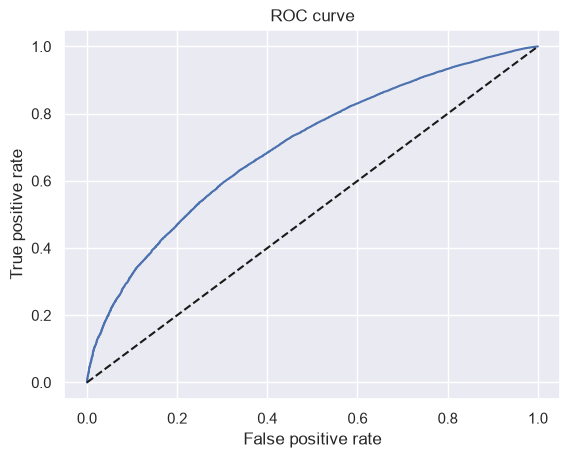

In [124]:
plt.plot(fpr, tpr)
plt.plot(fpr, fpr, linestyle = '--', color = 'k')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')

In [125]:
thresholds.shape

(17341,)

In [126]:
df_cutoffs = pd.concat([pd.DataFrame(thresholds), pd.DataFrame(fpr), pd.DataFrame(tpr)], axis = 1)

In [127]:
df_cutoffs.columns = ['thresholds', 'fpr', 'tpr']

In [128]:
df_cutoffs.head()

,thresholds,fpr,tpr
0,inf,0.000000,0.000000
1,0.992115,0.000000,0.000012
2,0.992097,0.000098,0.000012
3,0.989683,0.000098,0.000433
4,0.989673,0.000196,0.000433


In [129]:
df_cutoffs['Score'] = ((np.log(df_cutoffs['thresholds'] / (1 - df_cutoffs['thresholds'])) - min_sum_coef) * ((max_score - min_score) / (max_sum_coef - min_sum_coef)) + min_score).round()

In [130]:
df_cutoffs.head()

,thresholds,fpr,tpr,Score
0,inf,0.000000,0.000000,NaN
1,0.992115,0.000000,0.000012,777.000000
2,0.992097,0.000098,0.000012,777.000000
3,0.989683,0.000098,0.000433,754.000000
4,0.989673,0.000196,0.000433,754.000000


In [131]:
df_cutoffs.loc[0,'Score']= max_score

In [132]:
def n_approved(p):
    return np.where(df_actual_predicted_probs['y_hat_test_proba'] >= p, 1, 0).sum()

In [133]:
df_cutoffs['N Approved'] = df_cutoffs['thresholds'].apply(n_approved)
df_cutoffs['N Rejected'] = df_actual_predicted_probs['y_hat_test_proba'].shape[0] - df_cutoffs['N Approved']
df_cutoffs['Approval Rate'] = df_cutoffs['N Approved'] / df_actual_predicted_probs['y_hat_test_proba'].shape[0]
df_cutoffs['Rejection Rate'] = 1 - df_cutoffs['Approval Rate']

In [134]:
df_cutoffs.head()

,thresholds,fpr,tpr,Score,N Approved,N Rejected,Approval Rate,Rejection Rate
0,inf,0.000000,0.000000,850.000000,0,93257,0.000000,1.000000
1,0.992115,0.000000,0.000012,777.000000,1,93256,0.000011,0.999989
2,0.992097,0.000098,0.000012,777.000000,2,93255,0.000021,0.999979
3,0.989683,0.000098,0.000433,754.000000,37,93220,0.000397,0.999603
4,0.989673,0.000196,0.000433,754.000000,38,93219,0.000407,0.999593


In [135]:
df_cutoffs.tail()

,thresholds,fpr,tpr,Score,N Approved,N Rejected,Approval Rate,Rejection Rate
17336,0.493946,0.999804,0.999964,366.000000,93252,5,0.999946,0.000054
17337,0.484424,0.999804,0.999976,363.000000,93253,4,0.999957,0.000043
17338,0.482675,0.999902,0.999976,362.000000,93254,3,0.999968,0.000032
17339,0.469657,0.999902,1.000000,358.000000,93256,1,0.999989,0.000011
17340,0.466930,1.000000,1.000000,357.000000,93257,0,1.000000,0.000000


In [141]:
# set 90%?
df_test_90 = df_cutoffs[(df_cutoffs['thresholds']>=0.88) &(df_cutoffs['thresholds']<=0.92)]
df_test_90

,thresholds,fpr,tpr,Score,N Approved,N Rejected,Approval Rate,Rejection Rate
3445,0.919973,0.176251,0.438839,575.000000,38249,55008,0.410146,0.589854
3446,0.919973,0.176349,0.438839,575.000000,38250,55007,0.410157,0.589843
3447,0.919950,0.176349,0.439079,575.000000,38270,54987,0.410371,0.589629
3448,0.919949,0.176447,0.439079,575.000000,38271,54986,0.410382,0.589618
3449,0.919943,0.176447,0.439152,575.000000,38277,54980,0.410446,0.589554
3450,0.919938,0.176546,0.439152,575.000000,38278,54979,0.410457,0.589543
3451,0.919933,0.176546,0.439188,575.000000,38281,54976,0.410489,0.589511
3452,0.919933,0.176644,0.439188,575.000000,38282,54975,0.410500,0.589500
3453,0.919923,0.176644,0.439320,575.000000,38293,54964,0.410618,0.589382
3454,0.919922,0.176742,0.439320,575.000000,38294,54963,0.410629,0.589371
